In [1]:
import sys
import os
import pandas as pd
import numpy as np
import torch
import copy
import pandas as pd
import torch
import yaml


In [2]:
total_return = pd.read_csv("subperiod_total_average.csv", index_col=0, parse_dates=True)

In [3]:
corona_start = "2020-02-29"
corona_end = "2022-06-30"

In [4]:
befor_pandemic = total_return.loc[total_return.index <= corona_start]
pandemic = total_return.loc[(total_return.index > corona_start) & (total_return.index <= corona_end)]
post_pandemic = total_return.loc[total_return.index > corona_end]

In [5]:
befor_pandemic.index[0], befor_pandemic.index[-1], \
pandemic.index[0], pandemic.index[-1], \
post_pandemic.index[0], post_pandemic.index[-1]

(Timestamp('2019-01-30 00:00:00'),
 Timestamp('2020-02-11 00:00:00'),
 Timestamp('2020-03-11 00:00:00'),
 Timestamp('2022-06-29 00:00:00'),
 Timestamp('2022-07-28 00:00:00'),
 Timestamp('2024-12-31 00:00:00'))

In [ ]:
# befor_pandemic.to_csv("befor_pandemic.csv")
# pandemic.to_csv("pandemic.csv")
# post_pandemic.to_csv("post_pandemic.csv")

In [6]:
import statsmodels.api as sm
from statsmodels.stats.sandwich_covariance import cov_hac
from scipy.stats import t

def newey_west_tstat(returns, maxlags=1):
    """
    논문 방식에 따른 Newey-West t-통계량 계산 함수
    입력:
        returns: 수익률 벡터 (list, np.array, pd.Series)
        maxlags: Newey-West 보정에 사용할 최대 시차
    출력:
        (평균 수익률, NW 표준오차, NW t-통계량)
    """
    returns = np.asarray(returns)
    T = len(returns)
    X = np.ones((T, 1))  # 상수항만 포함 (평균 추정)
    
    model = sm.OLS(returns, X).fit(cov_type='HAC', cov_kwds={'maxlags': maxlags})
    nw_cov = cov_hac(model, nlags=maxlags)
    # nw_se = np.sqrt(nw_cov[0, 0])
    # t_stat = model.params[0] / nw_se
    
    return model.params[0], model.bse[0], model.tvalues[0]

In [7]:
# describe_df = pd.DataFrame()
# for i in befor_pandemic.columns:
#     imp = befor_pandemic[i]
#     print(imp.describe())
#     print("skew", imp.skew())
#     print("kurtosis", imp.kurtosis())
#     mean_return, nw_se, nw_tstat = newey_west_tstat(imp, maxlags=12)
#     p_value = 1 - t.cdf(nw_tstat, df=len(imp))

#     describe_df = pd.concat([describe_df, imp.describe().to_frame(name=i).T], axis=0)
#     describe_df.loc[i, "skew"] = imp.skew()
#     describe_df.loc[i, "kurtosis"] = imp.kurtosis()
#     describe_df.loc[i, "mean_return"] = mean_return
#     describe_df.loc[i, "nw_tstat"] = nw_tstat
#     describe_df.loc[i, "p_value"] = p_value


describe_df = pd.DataFrame()
for i in pandemic.columns:
    imp = pandemic[i]
    print(imp.describe())
    print("skew", imp.skew())
    print("kurtosis", imp.kurtosis())
    mean_return, nw_se, nw_tstat = newey_west_tstat(imp, maxlags=12)
    p_value = 1 - t.cdf(nw_tstat, df=len(imp))

    describe_df = pd.concat([describe_df, imp.describe().to_frame(name=i).T], axis=0)
    describe_df.loc[i, "skew"] = imp.skew()
    describe_df.loc[i, "kurtosis"] = imp.kurtosis()
    describe_df.loc[i, "mean_return"] = mean_return
    describe_df.loc[i, "nw_tstat"] = nw_tstat
    describe_df.loc[i, "p_value"] = p_value
    
# describe_df = pd.DataFrame()
# for i in post_pandemic.columns:
#     imp = post_pandemic[i]
#     print(imp.describe())
#     print("skew", imp.skew())
#     print("kurtosis", imp.kurtosis())
#     mean_return, nw_se, nw_tstat = newey_west_tstat(imp, maxlags=12)
#     p_value = 1 - t.cdf(nw_tstat, df=len(imp))

#     describe_df = pd.concat([describe_df, imp.describe().to_frame(name=i).T], axis=0)
#     describe_df.loc[i, "skew"] = imp.skew()
#     describe_df.loc[i, "kurtosis"] = imp.kurtosis()
#     describe_df.loc[i, "mean_return"] = mean_return
#     describe_df.loc[i, "nw_tstat"] = nw_tstat
#     describe_df.loc[i, "p_value"] = p_value
        

count    30.000000
mean      0.011284
std       0.043732
min      -0.093552
25%      -0.006535
50%       0.021401
75%       0.033330
max       0.095906
Name: GRPO, dtype: float64
skew -0.6411578528899323
kurtosis 0.5721029586211794
count    30.000000
mean      0.012040
std       0.050950
min      -0.145655
25%      -0.008886
50%       0.021216
75%       0.031367
max       0.108859
Name: PPO, dtype: float64
skew -1.045522985684433
kurtosis 2.3716753089300986
count    30.000000
mean      0.009261
std       0.048961
min      -0.132097
25%      -0.001313
50%       0.013416
75%       0.034696
max       0.093705
Name: SAC, dtype: float64
skew -1.081416916432967
kurtosis 2.0962029226258196
count    30.000000
mean      0.003264
std       0.053161
min      -0.161342
25%      -0.016510
50%       0.004417
75%       0.035768
max       0.108859
Name: risk_parity, dtype: float64
skew -0.8673990904698543
kurtosis 2.225335574309281
count    30.000000
mean      0.006792
std       0.035343
min      -0.0

In [8]:
describe_df.T

,GRPO,PPO,SAC,risk_parity,min_var,max_sharpe,paa,equal_strategy,equal_asset_weight
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,0.011284,0.012040,0.009261,0.003264,0.006792,0.008858,0.013085,0.008000,0.005819
std,0.043732,0.050950,0.048961,0.053161,0.035343,0.051465,0.071957,0.044339,0.057448
min,-0.093552,-0.145655,-0.132097,-0.161342,-0.087862,-0.144492,-0.156020,-0.124694,-0.146476
25%,-0.006535,-0.008886,-0.001313,-0.016510,-0.016472,-0.022990,-0.034427,-0.003361,-0.017762
50%,0.021401,0.021216,0.013416,0.004417,0.019909,0.021401,0.011824,0.019686,0.011853
75%,0.033330,0.031367,0.034696,0.035768,0.035045,0.033154,0.070920,0.030915,0.034990
max,0.095906,0.108859,0.093705,0.108859,0.058533,0.095906,0.178793,0.077159,0.137750
skew,-0.641158,-1.045523,-1.081417,-0.867399,-0.892007,-0.980255,-0.070220,-1.347028,-0.525547
kurtosis,0.572103,2.371675,2.096203,2.225336,0.382919,1.671303,0.225296,2.366820,1.446384


In [9]:
def convert_to_log_returns(returns):
    """
    단순 수익률 데이터를 로그 수익률로 변환합니다.
    log(1 + r_t)
    """
    returns = np.asarray(returns, dtype=np.float64)
    return np.log1p(returns)  # np.log1p(x) = log(1 + x), 정확도 ↑

def calculate_log_cumulative_returns(returns):
    """
    누적 로그 수익률 시계열을 반환합니다.
    """
    log_returns = convert_to_log_returns(returns)
    return np.cumsum(log_returns)  # 시계열 형태로 반환


def calculate_annual_return(returns, annual_factor=252):
    returns = np.array(returns, dtype=np.float64)
    cumulative = np.prod(1 + returns)
    n_periods = len(returns)
    return cumulative ** (annual_factor / n_periods) - 1


def calculate_max_drawdown(returns):
    returns = np.array(returns, dtype=np.float64)
    cumulative_returns = np.cumprod(1 + returns)
    running_max = np.maximum.accumulate(cumulative_returns)
    drawdowns = (cumulative_returns - running_max) / running_max
    return abs(np.min(drawdowns))

def calculate_volatility(returns, annual_factor=252):
    returns = np.asarray(returns)
    return np.std(returns, ddof=1) * np.sqrt(annual_factor)


def calculate_downside_deviation(returns, threshold=0.0, annual_factor=252, annualize=True):
    downside = np.minimum(returns - threshold, 0)
    dd = np.sqrt(np.mean(downside ** 2))
    return dd * np.sqrt(annual_factor) if annualize else dd


def calculate_annualized_sortino_ratio(returns, risk_free_rate=0.02, annual_factor=252):
    annual_return = calculate_annual_return(returns, annual_factor)
    excess_return = annual_return - risk_free_rate
    downside_dev = calculate_downside_deviation(returns, threshold=0.0, annual_factor=annual_factor)
    return excess_return / downside_dev if downside_dev != 0 else 0.0


def calculate_calmar_ratio(returns, annual_factor=252):
    """
    Calmar Ratio = Annualized Return / Maximum Drawdown
    """
    returns = np.array(returns, dtype=np.float64)
    annual_return = calculate_annual_return(returns, annual_factor)
    max_drawdown = calculate_max_drawdown(returns)
    
    return  (annual_return) / max_drawdown if max_drawdown != 0 else 0.0  # MDD가 0이면 0 반환


# def calculate_sharpe_ratio(returns, risk_free_rate=0.02, annual_factor=12):
#     returns = np.array(returns, dtype=np.float64)
#     geo_return = np.prod(1 + returns) ** (1 / len(returns)) - 1
#     risk_free_rate /= annual_factor
#     excess_geo_return = geo_return - risk_free_rate
#     std_dev = np.std(returns, ddof=1)
#     return (excess_geo_return * annual_factor) / (std_dev * np.sqrt(annual_factor)) if std_dev != 0 else 0.0

def calculate_sharpe_ratio(returns, risk_free_rate=0.02, annual_factor=252):
    returns = np.array(returns, dtype=np.float64)
    annual_return = calculate_annual_return(returns, annual_factor)
    excess_return =  (annual_return - risk_free_rate) 
    if excess_return == 0:
        sign = 1
    else:
        sign = excess_return / abs(excess_return)
    annual_std_dev = calculate_volatility(returns, annual_factor)
    # 연환산 수익률과 표준편차
    modified_sharpe =  excess_return / (annual_std_dev ** sign)  if annual_std_dev != 0 else 0.0
    return modified_sharpe


def calculate_cumulative_return(returns):
    returns = np.array(returns, dtype=np.float64)
    return np.prod(1 + returns) - 1

def calculate_volatility(returns, annual_factor=252):
    returns = np.asarray(returns)
    return np.std(returns, ddof=1) * np.sqrt(annual_factor)


# 성과 지표 계산 함수 (파라미터화)
def calculate_performance_metrics(returns, annual_factor=252, risk_free_rate=0.0):
    cumulative_returns = (1 + returns).cumprod()
    # cagr = calculate_cagr(returns, annual_factor)
    annual_return = calculate_annual_return(returns, annual_factor)
    sharpe_ratio = calculate_sharpe_ratio(returns, risk_free_rate, annual_factor)
    mdd = calculate_max_drawdown(returns)
    volatility = calculate_volatility(returns, annual_factor)
    sortino_ratio = calculate_annualized_sortino_ratio(returns, risk_free_rate, annual_factor)
    downside_deviation = calculate_downside_deviation(returns, threshold=0.0, annual_factor=annual_factor)
    # Calmar Ratio 계산
    calmar_ratio = calculate_calmar_ratio(returns, annual_factor)
    log_cumulative_return = np.sum(np.log1p(returns))

    return {
        'Cumulative Return': cumulative_returns.iloc[-1] - 1,
        'Log Cumulative Return': log_cumulative_return,

        'Annual Return': annual_return,
        # 'CAGR': cagr,
        'Volatility': volatility,
        'Sharpe Ratio': sharpe_ratio,
        'MDD': mdd,
        'Downside Deviation': downside_deviation,
        'Sortino Ratio': sortino_ratio,
        'Calmar Ratio': calmar_ratio
    }


# 성과 지표 요약 생성 함수 (파라미터 전달)
def get_performance_summary(returns_dict, annual_factor=252, risk_free_rate=0.0):
    metrics_df = pd.DataFrame()
    for name, returns in returns_dict.items():
        metrics_df[name] = calculate_performance_metrics(returns, annual_factor, risk_free_rate)
    return metrics_df.T


# 성과 지표 요약 생성 함수 (파라미터 전달)
def get_performance_summary(returns_dict, annual_factor=252, risk_free_rate=0.0):
    metrics_df = pd.DataFrame()
    for name, returns in returns_dict.items():
        metrics_df[name] = calculate_performance_metrics(returns, annual_factor, risk_free_rate)
    return metrics_df.T


import matplotlib.pyplot as plt
import numpy as np




In [10]:
factor_df = pd.DataFrame()
for col in befor_pandemic.columns:
    model = befor_pandemic[col]
    gross_profit = model[model >= 0].sum()
    gross_loss = model[model < 0].sum()
    profit_factor = gross_profit / abs(gross_loss) if gross_loss != 0 else np.nan
    print(f"gross_profit for {col}: {gross_profit:.4f}")
    print(f"gross_loss for {col}: {gross_loss:.4f}")
    print(f"Profit Factor for {col}: {profit_factor:.4f}")
    print("profitabel_months:", (befor_pandemic[col] > 0).sum())
    print("unprofitabel_months:", (befor_pandemic[col] < 0).sum())
    print("-"*50)
    factor_df[col] = {
        "gross_profit": gross_profit,
        "gross_loss": gross_loss,
        "profit_factor": profit_factor
    }

# for col in pandemic.columns:
#     model = pandemic[col]
#     gross_profit = model[model >= 0].sum()
#     gross_loss = model[model < 0].sum()
#     profit_factor = gross_profit / abs(gross_loss) if gross_loss != 0 else np.nan
#     print(f"gross_profit for {col}: {gross_profit:.4f}")
#     print(f"gross_loss for {col}: {gross_loss:.4f}")
#     print(f"Profit Factor for {col}: {profit_factor:.4f}")
#     print("profitabel_months:", (pandemic[col] > 0).sum())
#     print("unprofitabel_months:", (pandemic[col] < 0).sum())
#     print("-"*50)
#     factor_df[col] = {
#         "gross_profit": gross_profit,
#         "gross_loss": gross_loss,
#         "profit_factor": profit_factor
#     }

# for col in post_pandemic.columns:
#     model = post_pandemic[col]
#     gross_profit = model[model >= 0].sum()
#     gross_loss = model[model < 0].sum()
#     profit_factor = gross_profit / abs(gross_loss) if gross_loss != 0 else np.nan
#     print(f"gross_profit for {col}: {gross_profit:.4f}")
#     print(f"gross_loss for {col}: {gross_loss:.4f}")
#     print(f"Profit Factor for {col}: {profit_factor:.4f}")
#     print("profitabel_months:", (post_pandemic[col] > 0).sum())
#     print("unprofitabel_months:", (post_pandemic[col] < 0).sum())
#     print("-"*50)
#     factor_df[col] = {
#         "gross_profit": gross_profit,
#         "gross_loss": gross_loss,
#         "profit_factor": profit_factor
#     }

gross_profit for GRPO: 0.2093
gross_loss for GRPO: -0.0735
Profit Factor for GRPO: 2.8479
profitabel_months: 11
unprofitabel_months: 3
--------------------------------------------------
gross_profit for PPO: 0.1988
gross_loss for PPO: -0.0735
Profit Factor for PPO: 2.7044
profitabel_months: 11
unprofitabel_months: 3
--------------------------------------------------
gross_profit for SAC: 0.1219
gross_loss for SAC: -0.0851
Profit Factor for SAC: 1.4328
profitabel_months: 7
unprofitabel_months: 7
--------------------------------------------------
gross_profit for risk_parity: 0.2310
gross_loss for risk_parity: -0.0840
Profit Factor for risk_parity: 2.7516
profitabel_months: 10
unprofitabel_months: 4
--------------------------------------------------
gross_profit for min_var: 0.1725
gross_loss for min_var: -0.0434
Profit Factor for min_var: 3.9773
profitabel_months: 9
unprofitabel_months: 5
--------------------------------------------------
gross_profit for max_sharpe: 0.1069
gross_loss f

In [11]:
import portfolio_price_discrete_rebal_step_1m_concat_sharpe.result.robustsharpe as rs

In [12]:
ck_col = ['GRPO', 'PPO', 'SAC', 'risk_parity', 'min_var', 'max_sharpe', 'paa',
       'equal_strategy']

In [13]:
z = pd.DataFrame()

benchmark_returns = np.array(befor_pandemic["equal_asset_weight"])
for i in ck_col:
    test_returns = np.array(befor_pandemic[i])
    returns_t = np.stack([test_returns, benchmark_returns], axis=1)  # shape: (T, 2)
    SRs, diff, ci, pval, se, d = rs.bootstrap_inference(
        returns=returns_t,
        block_size=4,     # 논문 추천값 (T=120 기준)
        alpha=0.05,
        M=1000
    )
    print(f"Performance metrics for {i}:")
    # print("Sharpe ratio (벤치마크, 내):", SRs)
    # print("Sharpe ratio 차이:", diff)
    # print("95% 신뢰구간:", ci)
    print("t-통계량", d)
    print("p-value:", pval)
    print("----------------------------------")
    z[i] = {
        "t-stats": d,
        "p-value": pval
    }


# benchmark_returns = np.array(pandemic["equal_asset_weight"])
# for i in ck_col:
#     test_returns = np.array(pandemic[i])
#     returns_t = np.stack([test_returns, benchmark_returns], axis=1)  # shape: (T, 2)
#     SRs, diff, ci, pval, se, d = rs.bootstrap_inference(
#         returns=returns_t,
#         block_size=4,     # 논문 추천값 (T=120 기준)
#         alpha=0.05,
#         M=1000
#     )
#     print(f"Performance metrics for {i}:")
#     # print("Sharpe ratio (벤치마크, 내):", SRs)
#     # print("Sharpe ratio 차이:", diff)
#     # print("95% 신뢰구간:", ci)
#     print("t-통계량", d)
#     print("p-value:", pval)
#     print("----------------------------------")
#     z[i] = {
#         "t-stats": d,
#         "p-value": pval
#     }
    
# benchmark_returns = np.array(post_pandemic["equal_asset_weight"])
# for i in ck_col:
#     test_returns = np.array(post_pandemic[i])
#     returns_t = np.stack([test_returns, benchmark_returns], axis=1)  # shape: (T, 2)
#     SRs, diff, ci, pval, se, d = rs.bootstrap_inference(
#         returns=returns_t,
#         block_size=4,     # 논문 추천값 (T=120 기준)
#         alpha=0.05,
#         M=1000
#     )
#     print(f"Performance metrics for {i}:")
#     # print("Sharpe ratio (벤치마크, 내):", SRs)
#     # print("Sharpe ratio 차이:", diff)
#     # print("95% 신뢰구간:", ci)
#     print("t-통계량", d)
#     print("p-value:", pval)
#     print("----------------------------------")
#     z[i] = {
#         "t-stats": d,
#         "p-value": pval
#     }

Performance metrics for GRPO:
t-통계량 0.48700512879166635
p-value: 0.6413586413586414
----------------------------------
Performance metrics for PPO:
t-통계량 0.46322186571818885
p-value: 0.6663336663336663
----------------------------------
Performance metrics for SAC:
t-통계량 0.5155092799682911
p-value: 0.6413586413586414
----------------------------------
Performance metrics for risk_parity:
t-통계량 0.6799535611958477
p-value: 0.5144855144855145
----------------------------------
Performance metrics for min_var:
t-통계량 0.45578236857089777
p-value: 0.6573426573426573
----------------------------------
Performance metrics for max_sharpe:
t-통계량 0.9105951487858827
p-value: 0.44155844155844154
----------------------------------
Performance metrics for paa:
t-통계량 0.9247064177960463
p-value: 0.4325674325674326
----------------------------------
Performance metrics for equal_strategy:
t-통계량 0.3231003660816055
p-value: 0.7402597402597403
----------------------------------


In [14]:
metrics_summary = get_performance_summary(
    befor_pandemic,
    annual_factor=12,
    risk_free_rate=0.0
)

# display(metrics_summary)
# metrics_summary = get_performance_summary(
#     pandemic,
#     annual_factor=12,
#     risk_free_rate=0.0
# )

# display(metrics_summary)


# metrics_summary = get_performance_summary(
#     post_pandemic,
#     annual_factor=12,
#     risk_free_rate=0.0
# )

In [15]:
imp = pd.concat([metrics_summary.T, z], axis=0)


In [16]:
pd.concat([imp, factor_df], axis=0)

,GRPO,PPO,SAC,risk_parity,min_var,max_sharpe,paa,equal_strategy,equal_asset_weight
Cumulative Return,0.141307,0.129359,0.035138,0.152778,0.133812,-0.045034,-0.008507,0.056541,0.125581
Log Cumulative Return,0.132174,0.121650,0.034535,0.142174,0.125586,-0.046079,-0.008544,0.055001,0.118299
Annual Return,0.119959,0.109902,0.030044,0.129600,0.113652,-0.038727,-0.007296,0.048272,0.106719
Volatility,0.074457,0.075389,0.064616,0.088053,0.075447,0.076846,0.092506,0.064918,0.098871
Sharpe Ratio,1.611119,1.457790,0.464956,1.471841,1.506375,-0.002976,-0.000675,0.743596,1.079371
MDD,0.040886,0.040886,0.032960,0.040886,0.023336,0.051034,0.058057,0.033905,0.054910
Downside Deviation,0.045181,0.045181,0.038175,0.046208,0.021908,0.060432,0.061149,0.037950,0.057832
Sortino Ratio,2.655080,2.432481,0.786998,2.804704,5.187613,-0.640829,-0.119322,1.272005,1.845326
Calmar Ratio,2.933965,2.687985,0.911519,3.169775,4.870324,-0.758843,-0.125675,1.423773,1.943513
t-stats,0.487005,0.463222,0.515509,0.679954,0.455782,0.910595,0.924706,0.323100,NaN


In [17]:
zero_row_before = pd.DataFrame([[0]*befor_pandemic.shape[1]], columns=befor_pandemic.columns)
zero_row_pandemic = pd.DataFrame([[0]*pandemic.shape[1]], columns=pandemic.columns)
zero_row_post = pd.DataFrame([[0]*post_pandemic.shape[1]], columns=post_pandemic.columns)


In [18]:
zero_row_before.index = ["2019-01-01"]
zero_row_pandemic.index = ["2020-03-01"]
zero_row_post.index = ["2022-07-01"]

In [19]:
befor_pandemic = pd.concat([zero_row_before, befor_pandemic])
pandemic = pd.concat([zero_row_pandemic, pandemic])
post_pandemic = pd.concat([zero_row_post, post_pandemic])

In [20]:
rename_dict = {
    'risk_parity': 'Risk Parity',
    'min_var': 'Min Var',
    'max_sharpe': 'Max Sharpe',
    'paa': 'PAA',
    'equal_strategy': 'Equal Strategy',
    'equal_asset_weight' : 'Equal Asset Weight'
}

In [21]:
befor_pandemic.rename(columns=rename_dict, inplace=True)
pandemic.rename(columns=rename_dict, inplace=True)
post_pandemic.rename(columns=rename_dict, inplace=True)

In [25]:
total_return = total_return[['GRPO', 'PPO', 'SAC']]

In [26]:
import matplotlib.dates as mdates


In [27]:
def plot_cumulative_returns_subperiods(dfs: list,
                                       titles: list,
                                       y_ranges: list,
                                       test_start_date=None,
                                       figsize=(18, 5)):
    """
    3개의 기간별 cumulative return을 subplot으로 시각화
    """
    fig, axes = plt.subplots(1, 3, figsize=figsize, sharey=False)
    color_map = {
        'SAC': '#1f77b4',
        'Min Var': '#ff7f0e',
        'Max Sharpe': '#2ca02c',
        'PAA': '#e377c2',
        'Equal Strategy': '#8c564b',
        'Risk Parity': '#bcbd22',
        'Equal Asset Weight': '#7f7f7f',
        'GRPO': '#000000',
        'PPO': '#ff0000',
    }
    bold_strategies = ['GRPO', 'PPO', 'SAC']

    for i, (returns_df, title, y_range) in enumerate(zip(dfs, titles, y_ranges)):
        ax = axes[i]
        returns_df.index = pd.to_datetime(returns_df.index)
        cum_returns = np.log1p(returns_df).cumsum()

        for col in cum_returns.columns:
            linewidth = 3.5 if col in bold_strategies else 2.0
            color = color_map.get(col, None)
            ax.plot(cum_returns.index, cum_returns[col], label=col,
                    linewidth=linewidth, color=color)

        ax.set_title(title, fontsize=13)
        ax.set_ylim(y_range)
        ax.set_xlabel('Date', fontsize=11)

        if i == 0:
            ax.set_ylabel('Log Cumulative Returns', fontsize=11)
        else:
            ax.set_ylabel('')


        # ✅ X축 tick 간격: 첫 번째 subplot은 3개월, 나머지는 2개월
        # ✅ X축 tick 간격: subplot마다 다르게
        if i == 0:
            tick_interval = 3
        elif i == 1:
            tick_interval = 4
        else:
            tick_interval = 5

        tick_idx = returns_df.index[::tick_interval]
        ax.set_xticks(tick_idx)
        ax.set_xticklabels(tick_idx.strftime('%Y-%m'), rotation=45, fontsize=9)

        ax.tick_params(axis='x', labelsize=9)
        ax.tick_params(axis='y', labelsize=10)
        ax.grid(True)

        if test_start_date:
            ax.axvline(x=pd.to_datetime(test_start_date), color='red', linestyle='--', linewidth=2)

    # ✅ 범례: 아래, 최대 압축
    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.04),
               ncol=5, fontsize=9, frameon=False)

    # ✅ 제목 및 여백 최소화
    plt.suptitle("Monthly Log Cumulative Returns by Subperiod", fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.92])  # ✅ 하단 여백 극소화
    plt.savefig("figure/log_cum_return_subperiods.png", dpi=600, bbox_inches='tight')
    plt.show()


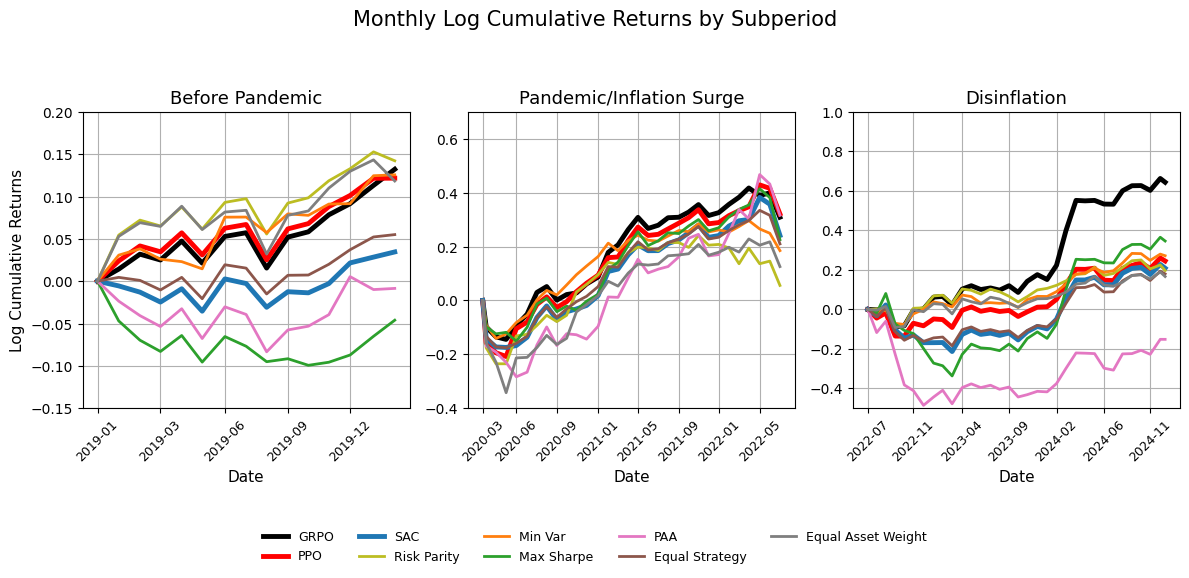

In [28]:
plot_cumulative_returns_subperiods(
    dfs=[befor_pandemic, pandemic, post_pandemic],
    titles=["Before Pandemic", "Pandemic/Inflation Surge", "Disinflation"],
    y_ranges=[(-0.15, 0.2), (-0.4, 0.7), (-0.5, 1)],
    figsize=(12, 5)
)


In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import math

def plot_subperiod_monthly_return_subplots(
    dfs: list,
    titles: list,
    strategy_order: list,
    benchmark_col: str = 'Equal Asset Weight',
    color: str = 'blue',
    figsize=(15, 12),
    save_path: str = None
):
    """
    서브기간별 전략별 월별 수익률을 subplot 행으로 수평 박스플롯으로 시각화합니다.

    Parameters:
    -----------
    dfs : list of pd.DataFrame
        각 서브기간별 수익률 데이터프레임 리스트

    titles : list of str
        각 subplot의 제목 (예: ["Before Pandemic", "Pandemic", "Post-Pandemic"])

    strategy_order : list of str
        각 subplot에 나타낼 전략 순서 (각 DataFrame에 공통적으로 존재해야 함)

    benchmark_col : str
        벤치마크 수평선 기준 컬럼명

    color : str
        박스 엣지 색상 (default: 'blue')

    figsize : tuple
        전체 figure 크기 (default: (15, 12))

    save_path : str or None
        저장 경로 지정 시 저장 (default: None)
    """
    n_periods = len(dfs)
    fig, axes = plt.subplots(n_periods, 1, figsize=figsize, sharex=True)
    benchmark_handle = None

    for i, (df, title) in enumerate(zip(dfs, titles)):
        ax = axes[i] if n_periods > 1 else axes
        benchmark_value = df[benchmark_col].mean()

        sns.boxplot(
            data=df[strategy_order],
            orient='h',
            width=0.5,
            fliersize=2.5,
            linewidth=1,
            ax=ax,
            showmeans=True,
            meanprops={
                "marker": "^",
                "markerfacecolor": "green",
                "markeredgecolor": "black",
                "markersize": 6
            },
            boxprops=dict(facecolor='white', edgecolor=color),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            medianprops=dict(color='black'),
        )
        # 수직선 추가 + handle 저장
        line = ax.axvline(
            x=benchmark_value,
            color='black',
            linestyle='--',
            linewidth=1.5,
            zorder=5,
            label=f"{benchmark_col} mean"
        )
        if benchmark_handle is None:  # 첫 subplot에서만 저장
            benchmark_handle = line

        ax.axvline(x=benchmark_value, color='black', linestyle='--', linewidth=1.5, zorder=5)
        ax.set_title(title, fontsize=12)
        ax.set_ylabel('')
        # ax.grid(axis='x', linestyle='--', linewidth=0.6, alpha=0.6)

        if i == n_periods - 1:
            ax.set_xlabel("Monthly Return", fontsize=11)
            # 마지막 subplot에만 legend 표시
            ax.legend(loc="lower right", fontsize=9)
        else:
            ax.set_xlabel('')

    # # fig.suptitle("Boxplots of Monthly Returns by Strategy in Each Subperiod", fontsize=14)
    # plt.tight_layout(rect=[0, 0, 1, 0.96])
    # if benchmark_handle is not None:
    #     fig.legend([benchmark_handle], [f"{benchmark_col} mean"],
    #                loc="lower right", fontsize=9)


    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.show()


In [71]:
before_df = befor_pandemic.iloc[1:]
pandemic_df = pandemic.iloc[1:]
post_df = post_pandemic.iloc[1:]

In [72]:
before_df = before_df[["GRPO", "PPO", "SAC", "Equal Asset Weight"]]
pandemic_df = pandemic_df[["GRPO", "PPO", "SAC", "Equal Asset Weight"]]
post_df = post_df[["GRPO", "PPO", "SAC", "Equal Asset Weight"]]

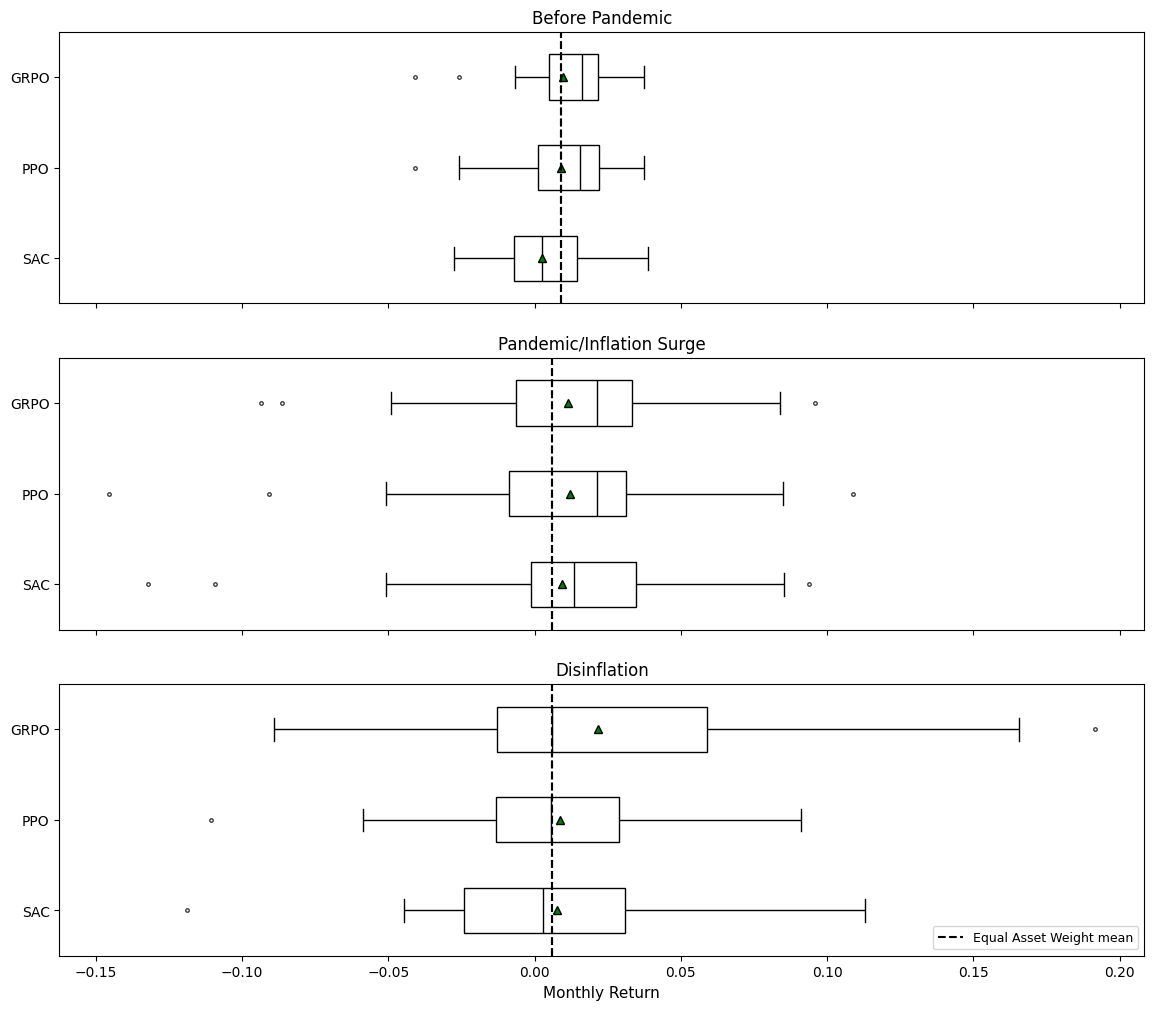

In [73]:
plot_subperiod_monthly_return_subplots(
    dfs=[before_df, pandemic_df, post_df],
    titles=["Before Pandemic", "Pandemic/Inflation Surge", "Disinflation"],
    # strategy_order=[
    #     'GRPO', 'PPO', 'SAC',
    #     'Risk Parity', 'Min Var', 'Max Sharpe',
    #     'PAA', 'Equal Strategy', 'Equal Asset Weight'
    # ],
    strategy_order=['GRPO', 'PPO', 'SAC'],
    benchmark_col='Equal Asset Weight',
    color='black',
    figsize=(14, 12),
    save_path="figure/monthly_return_by_subperiod.png"
)
